In [68]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
df = pd.read_csv('resultados_g.csv')
df.info()
df.describe()
print(f'Número de colunas: {len(df.columns)}')
print(f'Nomes das colunas: {df.columns}')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Columns: 101 entries, 0 to 100
dtypes: float64(101)
memory usage: 79.0 KB
Número de colunas: 101
Nomes das colunas: Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '91', '92', '93', '94', '95', '96', '97', '98', '99', '100'],
      dtype='object', length=101)


In [58]:
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 10)
display(df)

,0,1,2,3,4,...,96,97,98,99,100
0,2.829099,2.662018,2.655078,2.685568,2.604141,...,-2.448783,-2.556373,-1.848929,-2.388841,-2.687678
1,4.394318,4.439523,4.138244,4.538883,4.266607,...,1.482192,1.958508,0.773271,1.099709,1.567315
2,1.803631,1.906250,1.944632,1.738857,1.753304,...,-3.019652,-2.502138,-2.200298,-2.624234,-3.174260
3,3.011910,2.754918,2.997951,2.804833,3.036622,...,-0.583801,-0.223597,-1.122935,-1.043211,-0.804130
4,2.178335,2.098042,1.943929,2.008646,2.187250,...,-3.002137,-2.881732,-2.080859,-3.685325,-2.815555
...,...,...,...,...,...,...,...,...,...,...,...
95,3.922809,3.889332,3.846479,3.703276,4.092596,...,1.517221,0.913581,0.900250,0.701934,0.650717
96,2.461996,2.536128,2.277837,1.765509,2.291944,...,-3.743317,-3.343584,-3.023237,-3.722686,-3.811674
97,2.053743,2.165448,2.165462,2.132245,2.134563,...,-2.570232,-2.009204,-3.124966,-2.322172,-2.621475
98,4.829436,4.741682,4.652525,4.886111,4.656814,...,4.714315,4.834130,4.764605,4.717310,4.569578


In [54]:
results_g_médio = df.mean().to_frame(name='Medias')
display(results_g_médio)

,Medias
0,2.959977
1,2.946031
2,2.930792
3,2.962143
4,2.951723
5,2.954010
6,2.944896
7,2.945539
8,2.942895
9,2.929424


In [60]:
# Criando as features (lags) - COM 20 LAGS
results_g_médio['Target'] = results_g_médio['Medias'].shift(-1)


# Removendo linhas com valores nulos gerados pelos lags
results_g_médio = results_g_médio.fillna(-1.274643)
display(results_g_médio)


,Medias,Target
0,2.959977,2.946031
1,2.946031,2.930792
2,2.930792,2.962143
3,2.962143,2.951723
4,2.951723,2.954010
...,...,...
96,-1.098581,-1.152072
97,-1.152072,-1.129813
98,-1.129813,-1.120864
99,-1.120864,-1.274643


In [ ]:
for i in range 20:
    

In [62]:
X = results_g_médio.drop('Target', axis=1)
y = results_g_médio['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print(f'Tamanho do treino: {len(X_train)} samples')
print(f'Tamanho do teste: {len(X_test)} samples')

print(X_train.shape, X_test.shape)
print('Modelo Random Forest Regressor treinado.')

Tamanho do treino: 70 samples
Tamanho do teste: 31 samples
(70, 1) (31, 1)
Modelo Random Forest Regressor treinado.


In [70]:
y_pred = model.predict(X_test)
display(len(y_pred))

31

0.9978719328552178


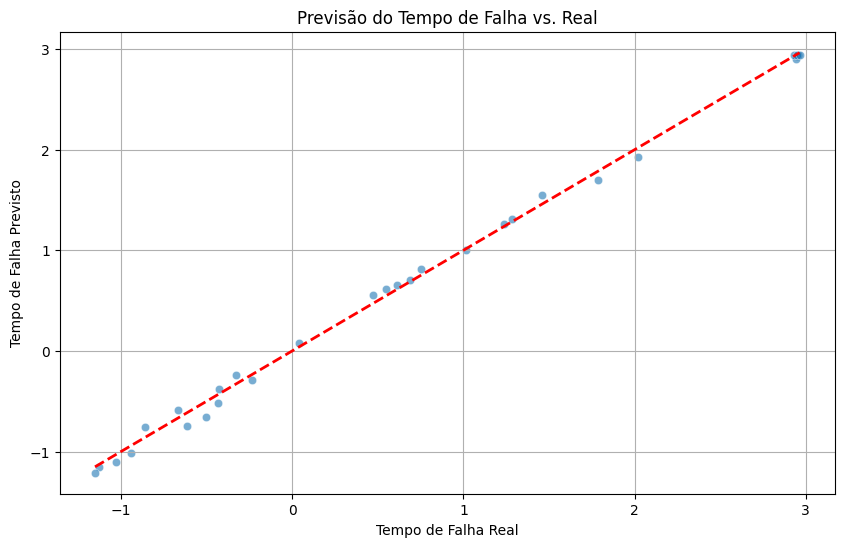

In [69]:
r2 = r2_score(y_test, y_pred)
print(r2)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Tempo de Falha Real')
plt.ylabel('Tempo de Falha Previsto')
plt.title('Previsão do Tempo de Falha vs. Real')
plt.grid(True)
plt.show()